<a href="https://colab.research.google.com/github/umang0015/Ai-DataScience/blob/main/5Aug.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.cluster.hierarchy import dendrogram , linkage
from sklearn.cluster import DBSCAN


In [ ]:
iris = load_iris()
X , y = iris.data, iris.target

X_scaled = StandardScaler().fit_transform(X)

In [ ]:
# fit agglomerative clustering(ward linkage , 3 clusters)
agg =  AgglomerativeClustering(n_clusters=3,linkage='ward')
labels= agg.fit_predict(X_scaled)
# evaluate
print(f"Adjusted Rand Index : {adjusted_rand_score(y , labels):.3f}")
print(f"Silhouette Score : {silhouette_score(X_scaled , labels):.3f}")

Adjusted Rand Index : 0.615
Silhouette Score : 0.447


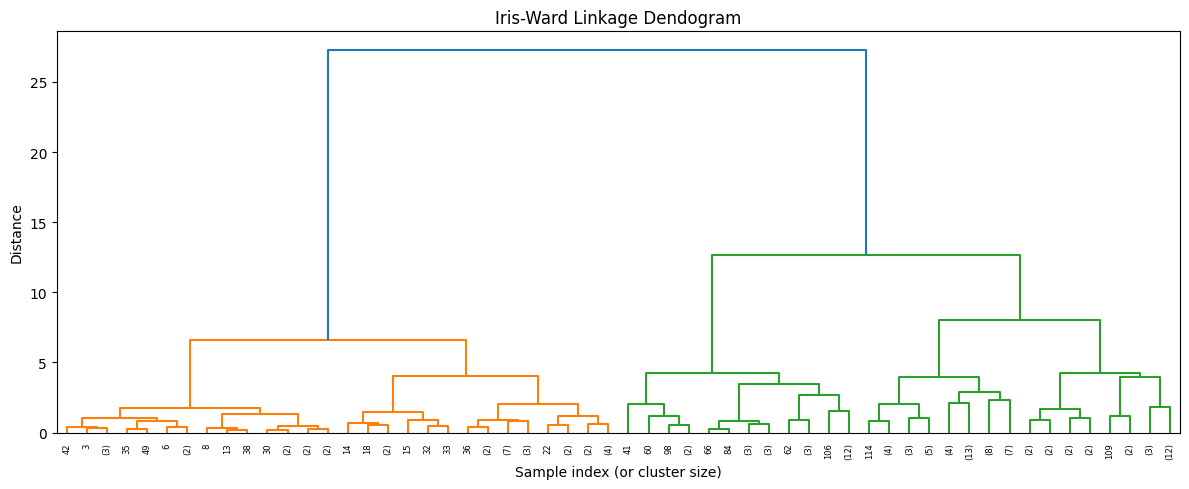

In [ ]:
# dendogram
plt.figure(figsize=(12,5))
Z = linkage(X_scaled , method = 'ward')
dendrogram(Z , truncate_mode = 'level' , p=5)
plt.title("Iris-Ward Linkage Dendogram")
plt.xlabel("Sample index (or cluster size)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [ ]:
X = load_iris().data
X = StandardScaler().fit_transform(X)

In [ ]:
db = DBSCAN(eps = 0.8 , min_samples=5)
labels = db.fit_predict(X)

In [ ]:
print(labels)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]


In [ ]:
print("CLusters: " , len(np.unique(labels[labels != 1])))
print("Noise points: " , (labels == -1).sum())

CLusters:  2
Noise points:  4


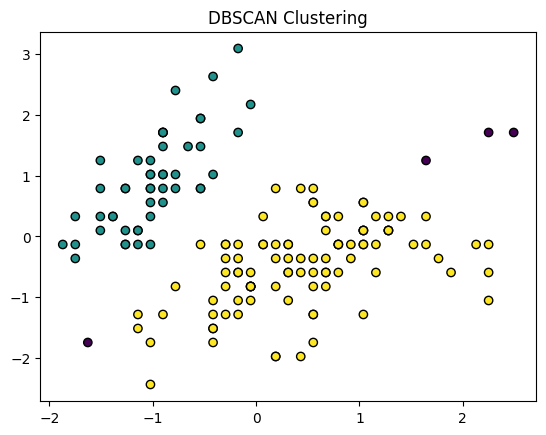

In [ ]:
plt.scatter(X[:, 0] , X[: , 1], c = labels,cmap='viridis' , edgecolor='k')
plt.title('DBSCAN Clustering')
plt.show()

In [ ]:
df = '/content/wine-clustering - wine-clustering.csv'
df = pd.read_csv(df)
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
df.isnull().sum()

,0
Alcohol,0
Malic_Acid,0
Ash,0
Ash_Alcanity,0
Magnesium,0
Total_Phenols,0
Flavanoids,0
Nonflavanoid_Phenols,0
Proanthocyanins,0
Color_Intensity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering , DBSCAN

In [ ]:
df.columns

Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline'],
      dtype='object')

In [ ]:
df.shape

(178, 13)

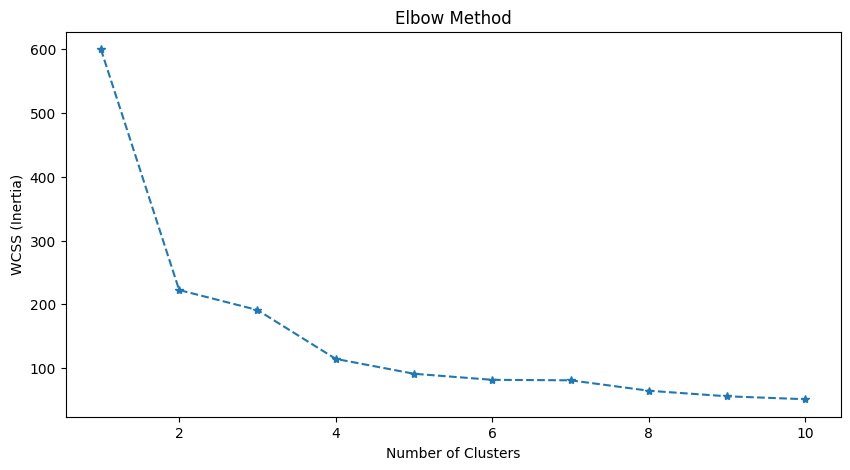

In [ ]:
scaler = StandardScaler()
X_wine = scaler.fit_transform(X)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_wine)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='*', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.show()

In [ ]:
best_k = 3
kmeans = KMeans(n_clusters = best_k , init='k-means++' , random_state=42)
kmeans_labels = kmeans.fit_predict(X_wine)

In [ ]:
# Check if data is scaled (mean should be ~0 and std should be ~1)
print(f"Mean of scaled data: {X_wine.mean():.4f}")
print(f"Standard deviation of scaled data: {X_wine.std():.4f}")

Mean of scaled data: 0.0000
Standard deviation of scaled data: 1.0000


In [ ]:
from sklearn.metrics import silhouette_score


results = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = km.fit_predict(X_wine)
    score = silhouette_score(X_wine, labels)
    results[k] = score
    print(f"K={k}, Silhouette Score: {score:.4f}")

best_k_silhouette = max(results, key=results.get)
print(f"\nBest K based on Silhouette Score: {best_k_silhouette}")

K=2, Silhouette Score: 0.5818
K=3, Silhouette Score: 0.4799
K=4, Silhouette Score: 0.3850
K=5, Silhouette Score: 0.3450
K=6, Silhouette Score: 0.3339

Best K based on Silhouette Score: 2


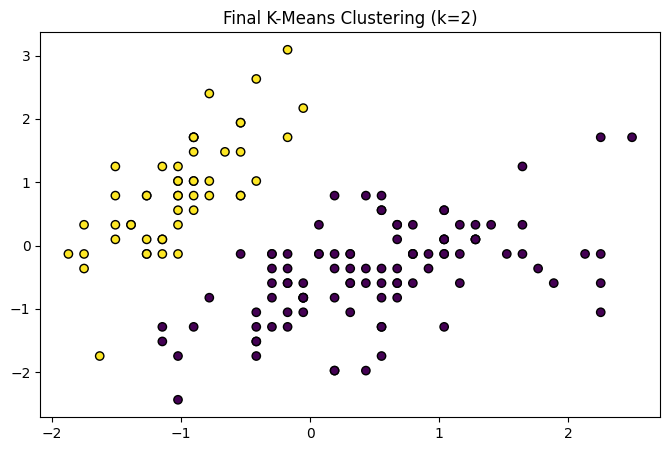

In [ ]:

final_kmeans = KMeans(n_clusters=best_k_silhouette, init='k-means++', random_state=42)
final_labels = final_kmeans.fit_predict(X_wine)

plt.figure(figsize=(8, 5))
plt.scatter(X_wine[:, 0], X_wine[:, 1], c=final_labels, cmap='viridis', edgecolor='k')
plt.title(f'Final K-Means Clustering (k={best_k_silhouette})')
plt.show()

Original feature count: 4
Reduced feature count: 2
Silhouette Score on PCA-reduced data: 0.6145


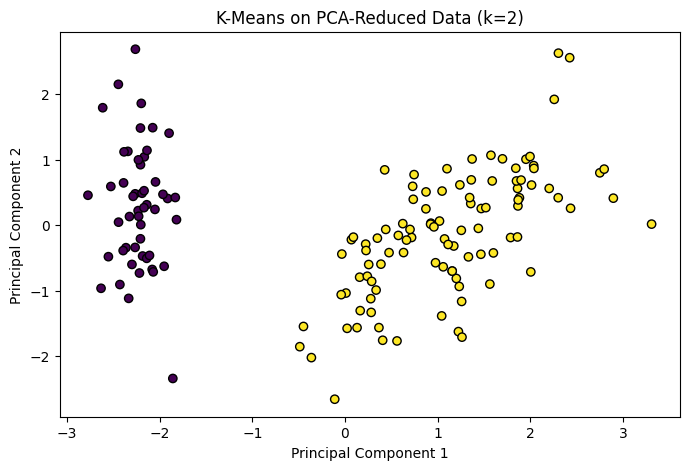

In [ ]:
from sklearn.decomposition import PCA


pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_wine)

print(f"Original feature count: {X_wine.shape[1]}")
print(f"Reduced feature count: {X_pca.shape[1]}")

km_pca = KMeans(n_clusters=best_k_silhouette, init='k-means++', random_state=42)
labels_pca = km_pca.fit_predict(X_pca)


s_score_pca = silhouette_score(X_pca, labels_pca)
print(f"Silhouette Score on PCA-reduced data: {s_score_pca:.4f}")


plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap='viridis', edgecolor='k')
plt.title(f'K-Means on PCA-Reduced Data (k={best_k_silhouette})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

using wine clustering data (defaults,loading, exploring,cleaning, scaling)
1. build Kmeans clustering model ,apply elbow to check best k

2 apply silhouette to verify it , plot clusters

3 apply DBSCAN and count noise , visualize clusters , compare cluster count against k mean

4. apply PCA , cover 95% variance ,
rebuild kmeans with reduced dimension, check cluster quality against original